# 🏥 Health Disease Prediction — XGBoost Multi-Label Classification
> **Pipeline:** Feature Understanding → EDA → Preprocessing → XGBoost → Evaluation
>
> **Goal:** Predict the presence of **10 diseases** from patient health indicators


## 1️⃣ Dataset Features — Full Explanation

### 🔵 Input Features (What we know about the patient)

| Feature | Type | Values | Description |
|---------|------|--------|-------------|
| `Age` | Numeric | 18 – 100 | Patient's age in years |
| `Gender` | Categorical | Male / Female | Biological sex of the patient |
| `Blood Pressure` | Categorical | Normal / High / Low | Blood pressure level |
| `Cholesterol` | Categorical | Normal / High / Low | Cholesterol level in blood |
| `Glucose` | Categorical | Normal / High / Low | Blood sugar level |
| `Smoking` | Categorical | Yes / No | Whether the patient smokes |
| `Alcohol Consumption` | Categorical | Yes / No | Whether the patient drinks alcohol |
| `Exercise` | Categorical | Yes / No | Whether the patient exercises regularly |
| `BMI` | Numeric | 18.5 – 50+ | Body Mass Index — weight relative to height |
| `Family History` | Categorical | Yes / No | Whether the patient has a family history of diseases |

---

### 🔴 Target Variables (Diseases to predict)

| Disease | Type | Prevalence | Description |
|---------|------|-----------|-------------|
| `Heart Disease` | Binary (0/1) | ~25% | Cardiovascular conditions affecting the heart |
| `Diabetes` | Binary (0/1) | ~19% | Inability to regulate blood sugar levels |
| `Stroke` | Binary (0/1) | ~13% | Interruption of blood supply to the brain |
| `Kidney Disease` | Binary (0/1) | ~14% | Chronic or acute kidney dysfunction |
| `Cancer` | Binary (0/1) | ~10% | Abnormal cell growth in the body |
| `Alzheimer's Disease` | Binary (0/1) | ~13% | Progressive brain disorder affecting memory |
| `COPD` | Binary (0/1) | ~10% | Chronic Obstructive Pulmonary Disease — lung condition |
| `Liver Disease` | Binary (0/1) | ~16% | Liver dysfunction or damage |
| `Parkinson's Disease` | Binary (0/1) | ~8% | Nervous system disorder affecting movement |
| `Tuberculosis` | Binary (0/1) | ~4% | Bacterial infection primarily affecting the lungs |

---

> **This is a Multi-Label problem** — a patient can have **more than one disease** at the same time.


## 2️⃣ Imports & Setup

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Libraries loaded successfully")
print(f"XGBoost version: {xgb.__version__}")


✅ Libraries loaded successfully
XGBoost version: 3.2.0


## 3️⃣ Load Dataset

In [5]:
df = pd.read_csv("healthcare_disease_prediction_dataset.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (1000, 20)


,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Gender               1000 non-null   object 
 2   Blood Pressure       1000 non-null   object 
 3   Cholesterol          1000 non-null   object 
 4   Glucose              1000 non-null   object 
 5   Smoking              1000 non-null   object 
 6   Alcohol Consumption  1000 non-null   object 
 7   Exercise             1000 non-null   object 
 8   BMI                  1000 non-null   float64
 9   Family History       1000 non-null   object 
 10  Heart Disease        1000 non-null   int64  
 11  Diabetes             1000 non-null   int64  
 12  Stroke               1000 non-null   int64  
 13  Kidney Disease       1000 non-null   int64  
 14  Cancer               1000 non-null   int64  
 15  Alzheimer's Disease  1000 non-null   in

In [7]:
df.describe(include="all")


,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
count,1000.000000,1000,1000,1000,1000,1000,1000,1000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
unique,NaN,2,3,2,2,2,2,2,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,Normal,Normal,Normal,Yes,No,Yes,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,503,352,514,510,502,505,505,NaN,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,52.881000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.213037,NaN,0.253000,0.186000,0.134000,0.142000,0.10000,0.130000,0.10100,0.157000,0.082000,0.035000
std,20.958915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.196368,NaN,0.434948,0.389301,0.340823,0.349225,0.30015,0.336472,0.30148,0.363983,0.274502,0.183872
min,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.504881,NaN,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,34.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.924004,NaN,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,52.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.892349,NaN,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,71.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.663806,NaN,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000


## 4️⃣ Exploratory Data Analysis (EDA)

### 📊 4.1 Disease Prevalence

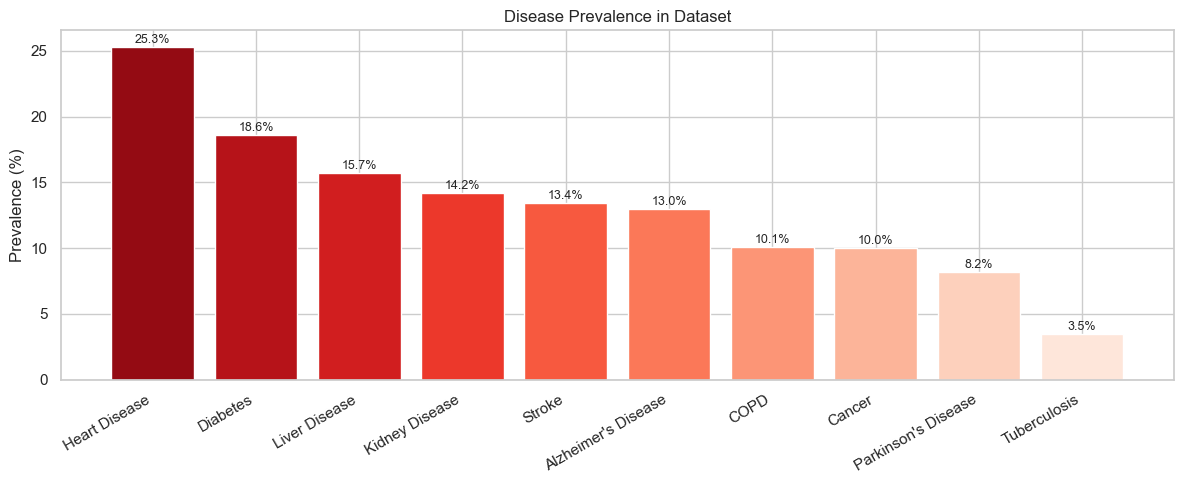

In [8]:
disease_cols = [
    "Heart Disease", "Diabetes", "Stroke", "Kidney Disease",
    "Cancer", "Alzheimer's Disease", "COPD", "Liver Disease",
    "Parkinson's Disease", "Tuberculosis"
]

prevalence = df[disease_cols].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 5))
bars = plt.bar(prevalence.index, prevalence.values,
               color=sns.color_palette("Reds_r", len(prevalence)))
plt.xticks(rotation=30, ha="right")
plt.ylabel("Prevalence (%)")
plt.title("Disease Prevalence in Dataset")
for bar, val in zip(bars, prevalence.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


### 👥 4.2 Patient Demographics

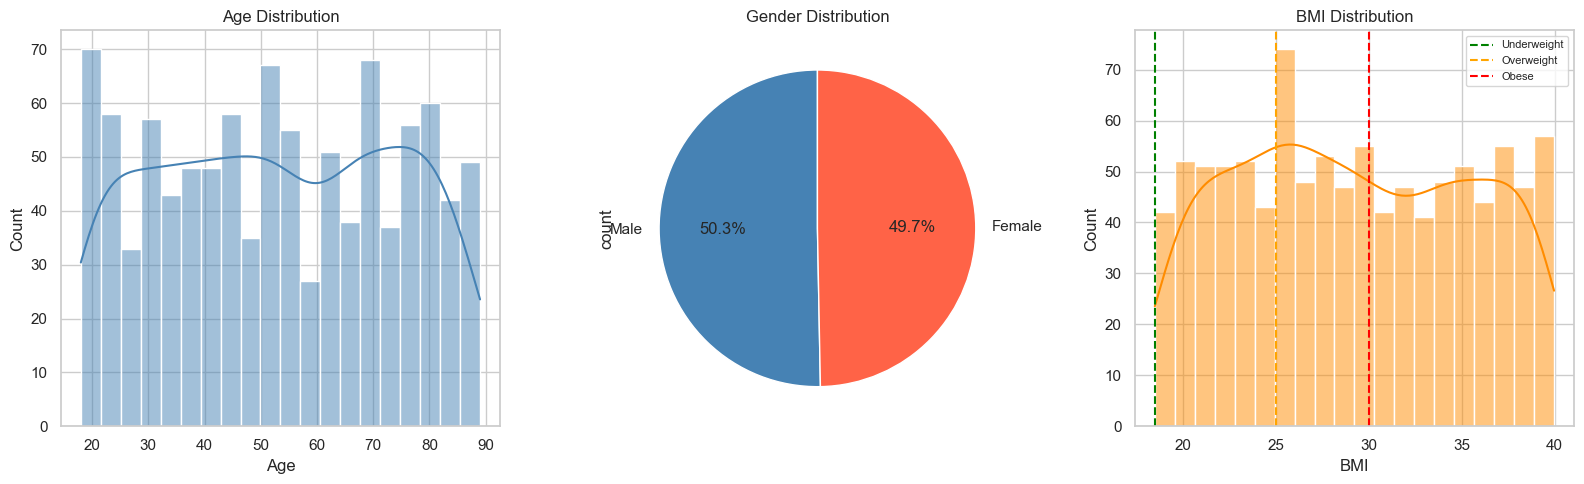

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution")

# Gender
df["Gender"].value_counts().plot(kind="pie", ax=axes[1],
    autopct="%1.1f%%", colors=["steelblue", "tomato"],
    startangle=90, title="Gender Distribution")

# BMI distribution
sns.histplot(df["BMI"], bins=20, kde=True, ax=axes[2], color="darkorange")
axes[2].set_title("BMI Distribution")
axes[2].axvline(18.5, color="green",  linestyle="--", label="Underweight")
axes[2].axvline(25.0, color="orange", linestyle="--", label="Overweight")
axes[2].axvline(30.0, color="red",    linestyle="--", label="Obese")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


### 🩺 4.3 Risk Factors Distribution

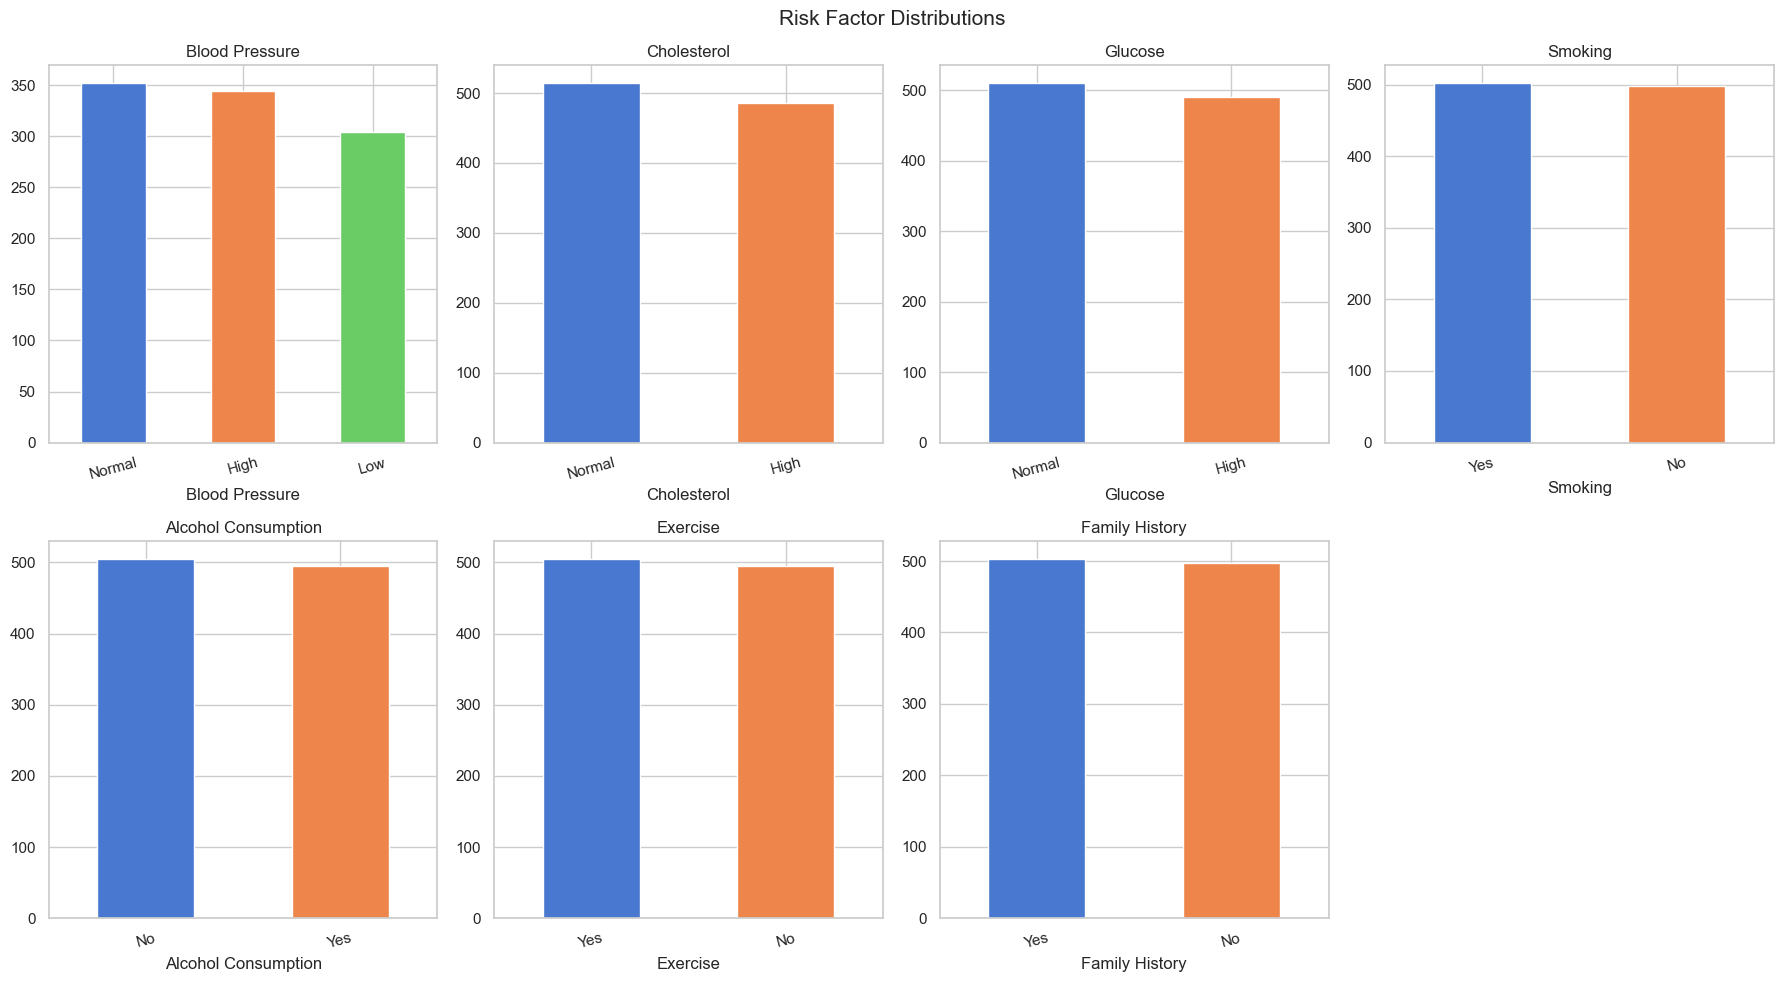

In [10]:
cat_features = ["Blood Pressure", "Cholesterol", "Glucose",
                "Smoking", "Alcohol Consumption", "Exercise", "Family History"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    df[col].value_counts().plot(kind="bar", ax=axes[i],
        color=sns.color_palette("muted"), edgecolor="white")
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=15)

axes[-1].set_visible(False)
plt.suptitle("Risk Factor Distributions", fontsize=15)
plt.tight_layout()
plt.show()


### 🔥 4.4 Risk Factors vs Each Disease

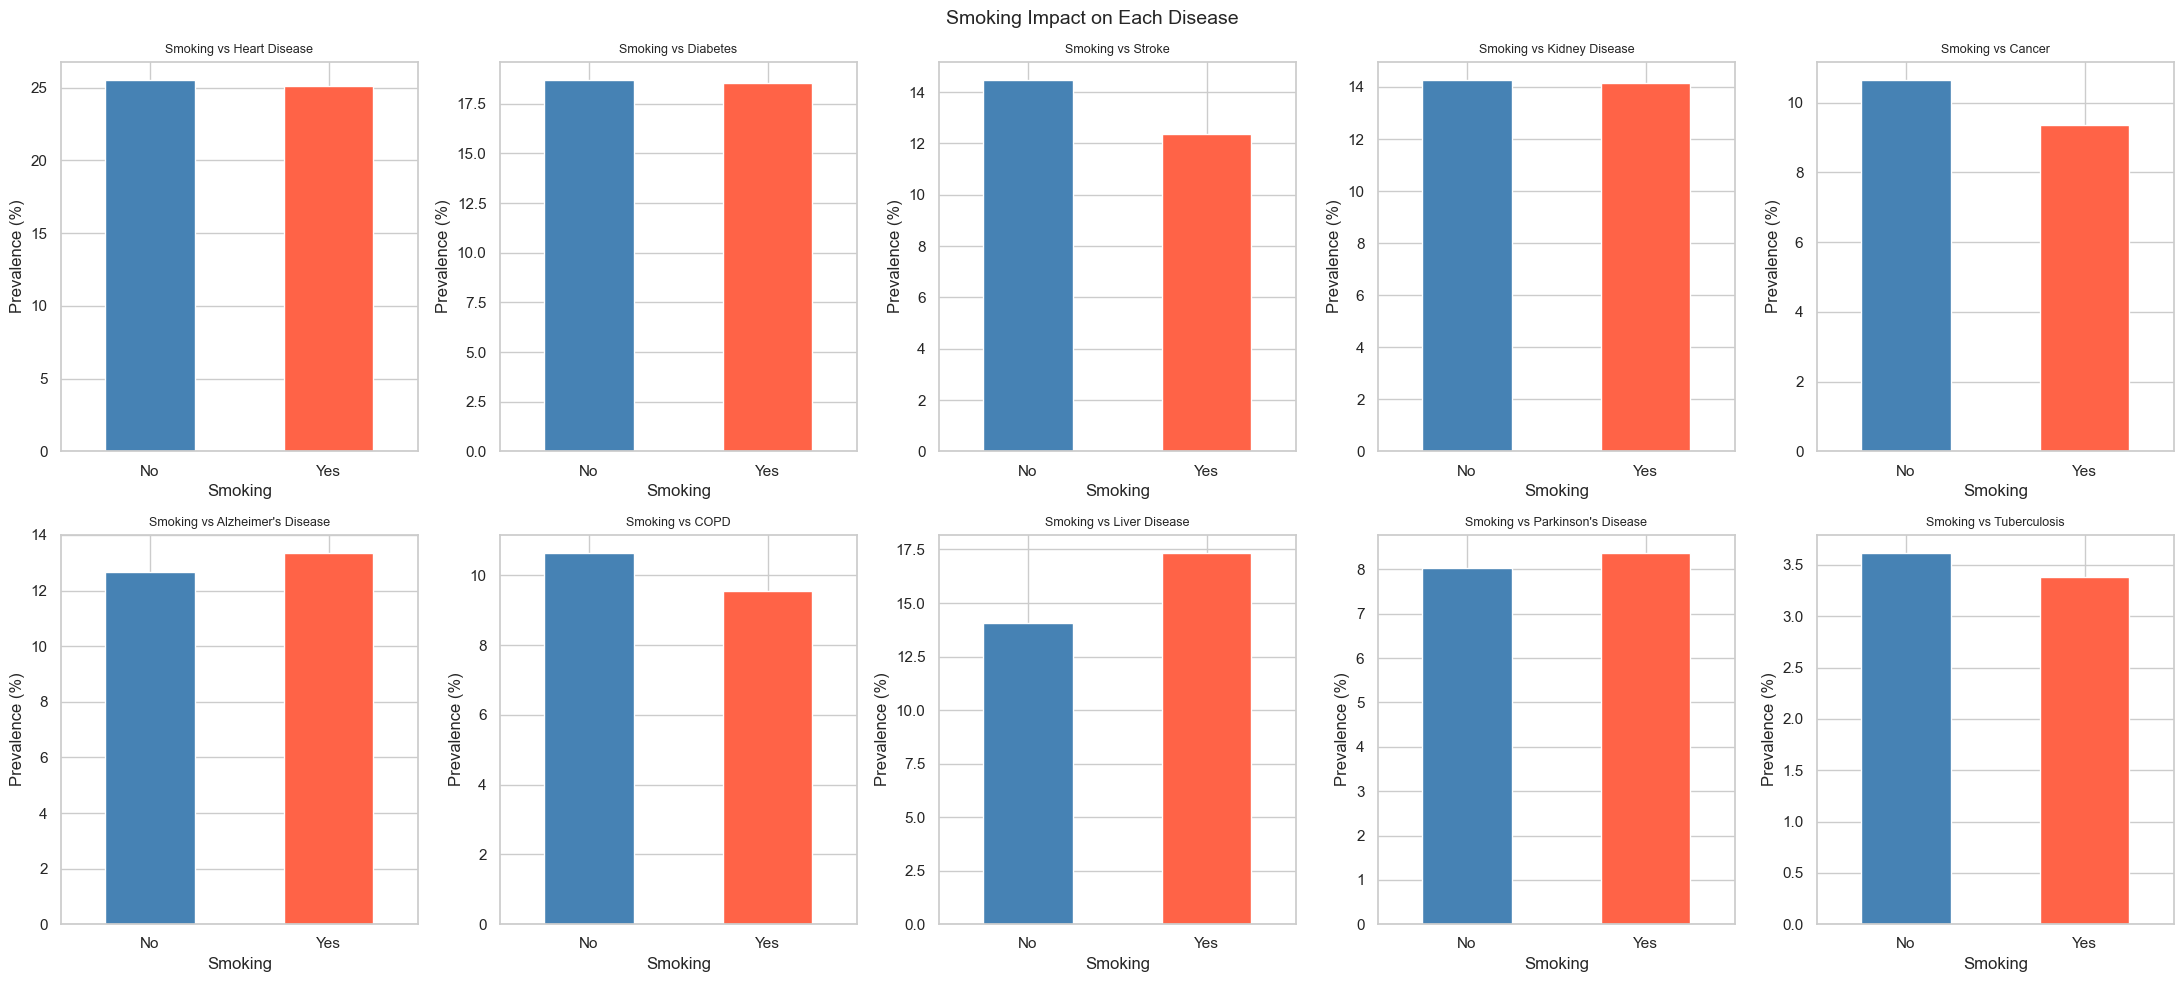

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, disease in enumerate(disease_cols):
    rate = df.groupby("Smoking")[disease].mean() * 100
    rate.plot(kind="bar", ax=axes[i],
              color=["steelblue", "tomato"], edgecolor="white")
    axes[i].set_title(f"Smoking vs {disease}", fontsize=9)
    axes[i].set_ylabel("Prevalence (%)")
    axes[i].tick_params(axis="x", rotation=0)

plt.suptitle("Smoking Impact on Each Disease", fontsize=14)
plt.tight_layout()
plt.show()


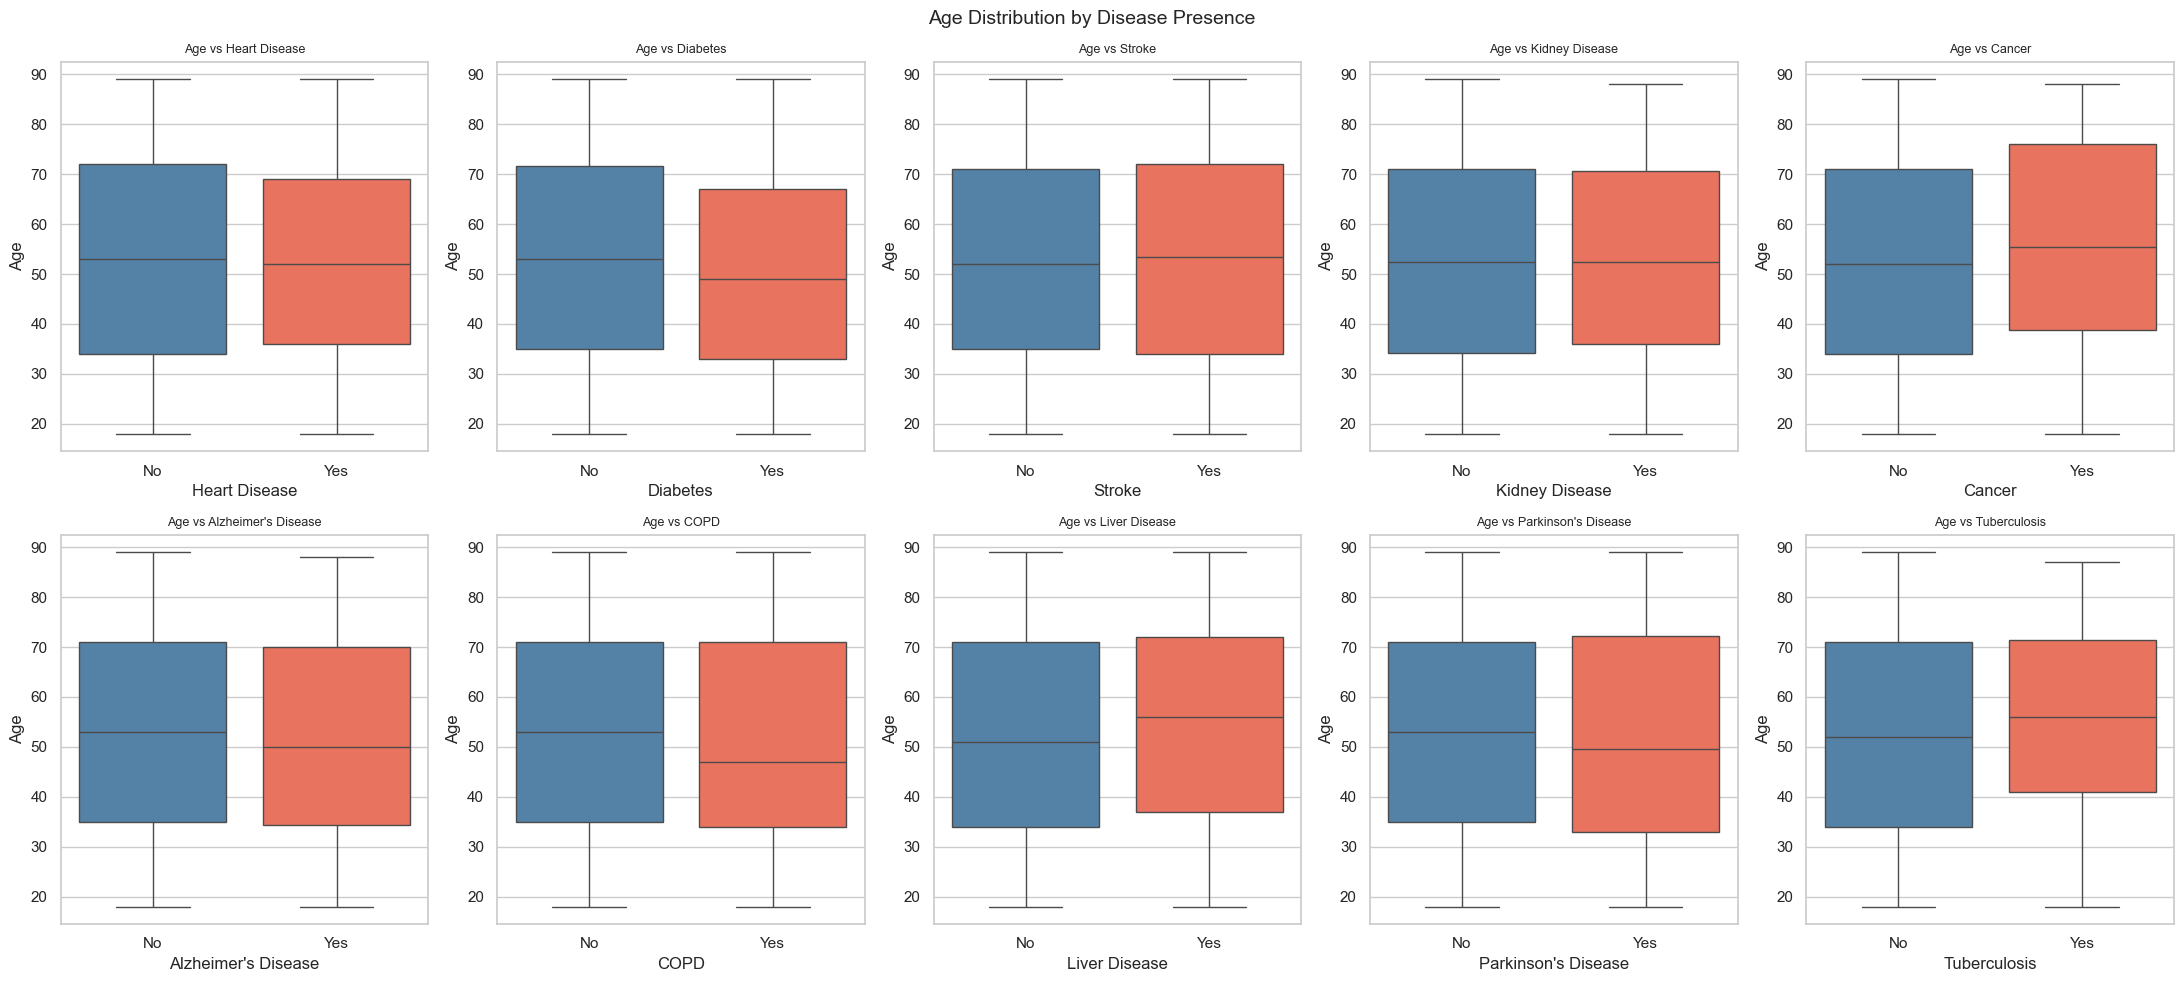

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, disease in enumerate(disease_cols):
    sns.boxplot(data=df, x=disease, y="Age", ax=axes[i],
                palette={"0": "steelblue", "1": "tomato"})
    axes[i].set_title(f"Age vs {disease}", fontsize=9)
    axes[i].set_xticklabels(["No", "Yes"])

plt.suptitle("Age Distribution by Disease Presence", fontsize=14)
plt.tight_layout()
plt.show()


### 🔗 4.5 Disease Co-occurrence Heatmap

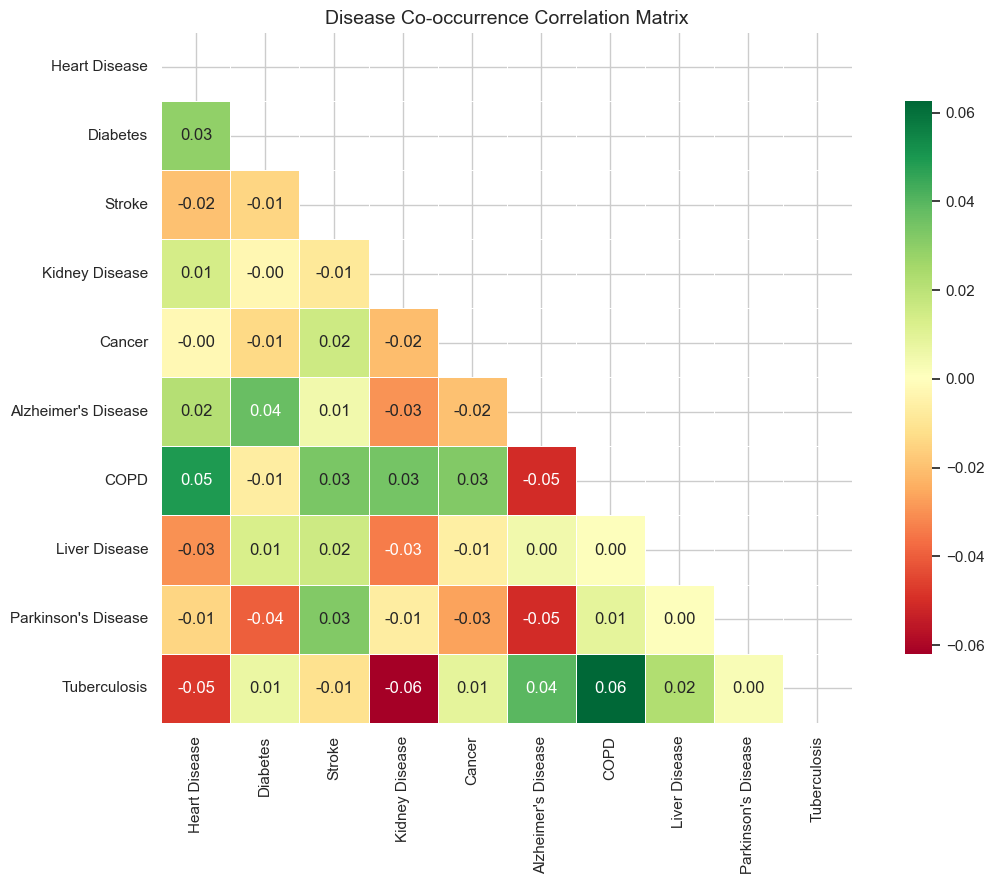

In [14]:
plt.figure(figsize=(12, 9))
corr = df[disease_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Disease Co-occurrence Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()


### 📈 4.6 BMI vs Disease

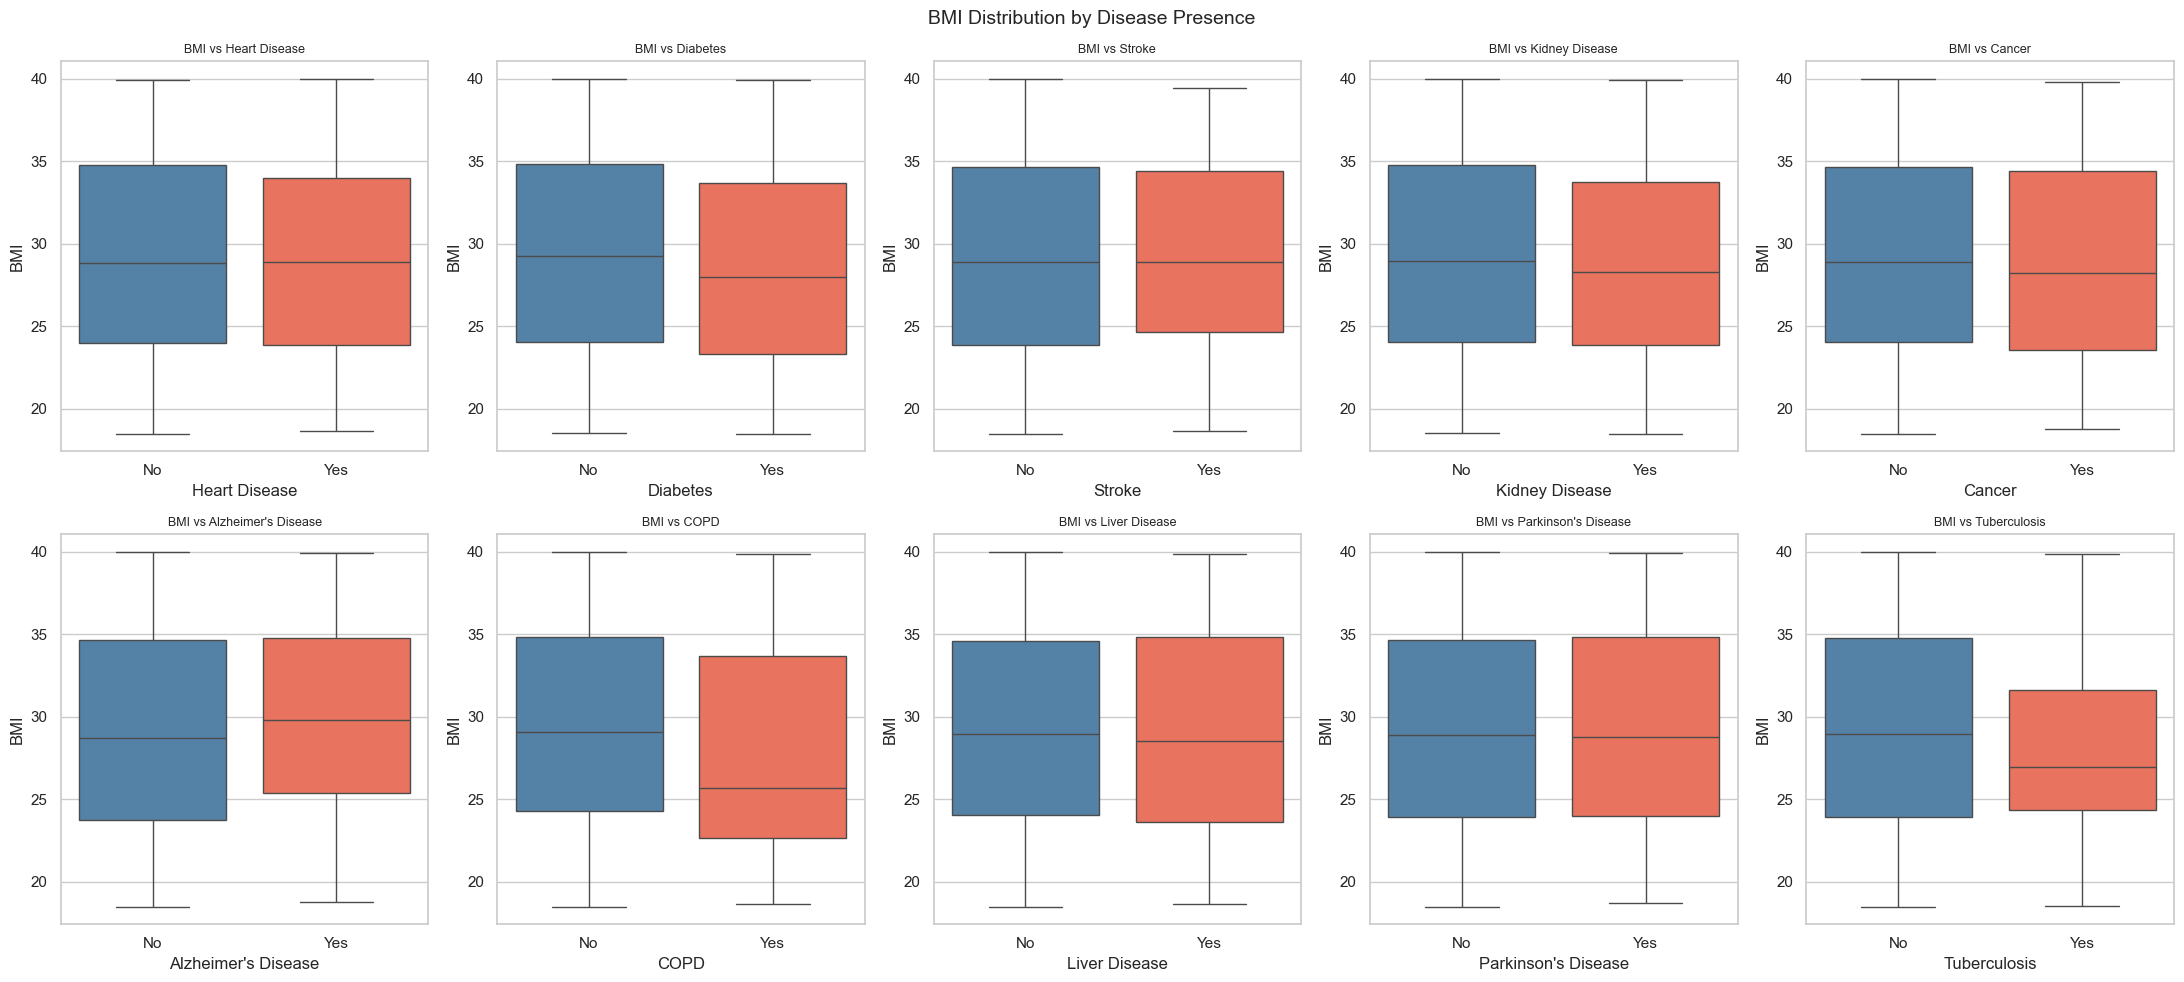

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, disease in enumerate(disease_cols):
    sns.boxplot(data=df, x=disease, y="BMI", ax=axes[i],
                palette={"0": "steelblue", "1": "tomato"})
    axes[i].set_title(f"BMI vs {disease}", fontsize=9)
    axes[i].set_xticklabels(["No", "Yes"])

plt.suptitle("BMI Distribution by Disease Presence", fontsize=14)
plt.tight_layout()
plt.show()


## 5️⃣ Preprocessing

In [17]:
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print("✅ No missing values — dataset is clean")


Missing values:
 Age                    0
Gender                 0
Blood Pressure         0
Cholesterol            0
Glucose                0
Smoking                0
Alcohol Consumption    0
Exercise               0
BMI                    0
Family History         0
Heart Disease          0
Diabetes               0
Stroke                 0
Kidney Disease         0
Cancer                 0
Alzheimer's Disease    0
COPD                   0
Liver Disease          0
Parkinson's Disease    0
Tuberculosis           0
dtype: int64

Duplicates: 0
✅ No missing values — dataset is clean


In [18]:
# Encode all categorical features
cat_cols = ["Gender", "Blood Pressure", "Cholesterol", "Glucose",
            "Smoking", "Alcohol Consumption", "Exercise", "Family History"]

le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("✅ Encoding done")
df_encoded.head(3)


✅ Encoding done


,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,1,0,0,0,1,0,0,35.671099,0,1,0,0,0,1,0,0,0,0,0
1,32,1,1,0,1,1,0,1,38.554188,1,0,1,0,0,0,0,0,1,0,0
2,89,0,2,0,1,0,0,1,18.932964,1,1,0,0,0,0,0,0,0,0,0


## 6️⃣ XGBoost — One Model per Disease

> We train a **separate XGBoost classifier** for each disease (Multi-Label via Binary Relevance strategy)


In [19]:
feature_cols = ["Age", "Gender", "Blood Pressure", "Cholesterol", "Glucose",
                "Smoking", "Alcohol Consumption", "Exercise", "BMI", "Family History"]

X = df_encoded[feature_cols]
results = {}

for disease in disease_cols:
    y = df_encoded[disease]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    )
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_pred_proba)
    except:
        auc = float("nan")

    results[disease] = {
        "model":   model,
        "X_test":  X_test,
        "y_test":  y_test,
        "y_pred":  y_pred,
        "y_proba": y_pred_proba,
        "acc":     acc,
        "auc":     auc
    }
    print(f"{disease:<25} | Accuracy: {acc:.4f} | AUC: {auc:.4f}")


Heart Disease             | Accuracy: 0.6800 | AUC: 0.5156
Diabetes                  | Accuracy: 0.7650 | AUC: 0.4822
Stroke                    | Accuracy: 0.8400 | AUC: 0.5072
Kidney Disease            | Accuracy: 0.8500 | AUC: 0.4487
Cancer                    | Accuracy: 0.8950 | AUC: 0.4500
Alzheimer's Disease       | Accuracy: 0.8600 | AUC: 0.6293
COPD                      | Accuracy: 0.8950 | AUC: 0.4992
Liver Disease             | Accuracy: 0.8000 | AUC: 0.4136
Parkinson's Disease       | Accuracy: 0.9100 | AUC: 0.4620
Tuberculosis              | Accuracy: 0.9650 | AUC: 0.5559


## 7️⃣ Results Summary

            Disease  Accuracy      AUC
Alzheimer's Disease     0.860 0.629310
       Tuberculosis     0.965 0.555885
      Heart Disease     0.680 0.515594
             Stroke     0.840 0.507172
               COPD     0.895 0.499167
           Diabetes     0.765 0.482175
Parkinson's Disease     0.910 0.461957
             Cancer     0.895 0.450000
     Kidney Disease     0.850 0.448713
      Liver Disease     0.800 0.413629


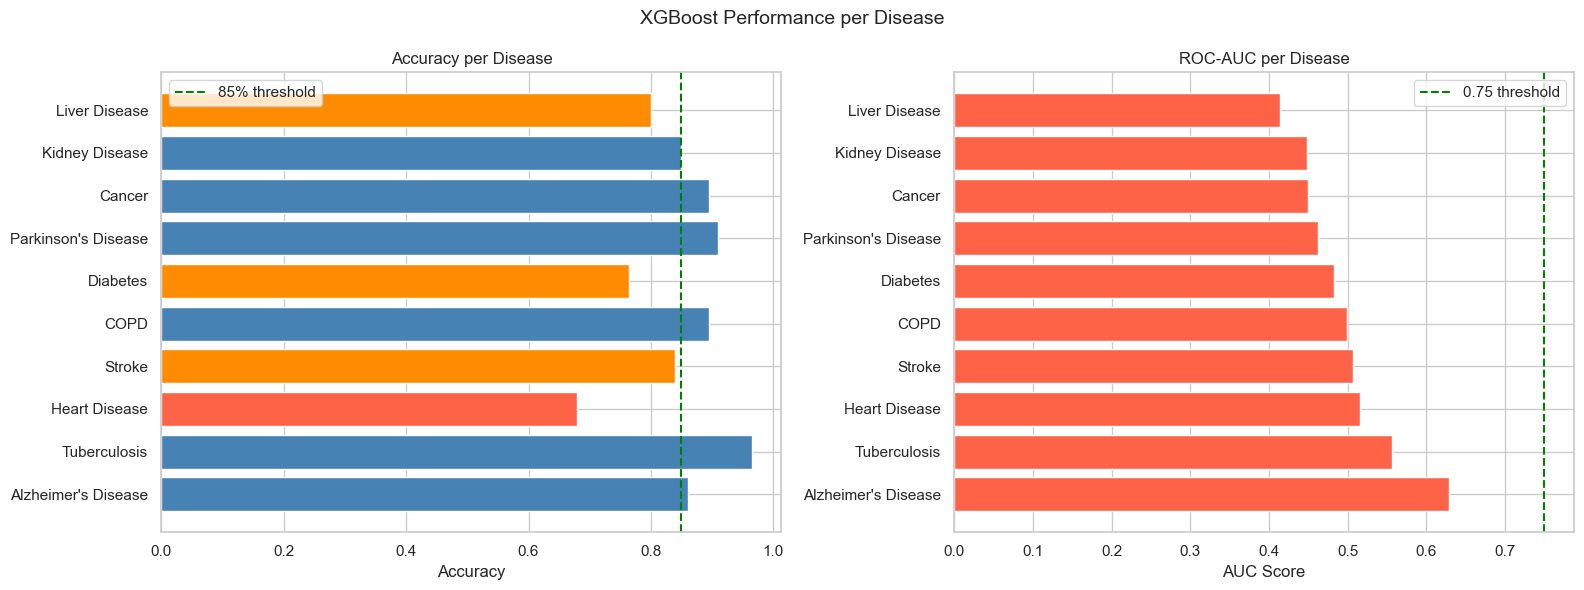

In [20]:
summary = pd.DataFrame({
    "Disease":  list(results.keys()),
    "Accuracy": [v["acc"] for v in results.values()],
    "AUC":      [v["auc"] for v in results.values()]
}).sort_values("AUC", ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
colors_acc = ["steelblue" if v >= 0.85 else "darkorange" if v >= 0.75 else "tomato"
              for v in summary["Accuracy"]]
axes[0].barh(summary["Disease"], summary["Accuracy"], color=colors_acc)
axes[0].axvline(0.85, color="green", linestyle="--", label="85% threshold")
axes[0].set_title("Accuracy per Disease")
axes[0].set_xlabel("Accuracy")
axes[0].legend()

# AUC
colors_auc = ["steelblue" if v >= 0.75 else "darkorange" if v >= 0.65 else "tomato"
              for v in summary["AUC"]]
axes[1].barh(summary["Disease"], summary["AUC"], color=colors_auc)
axes[1].axvline(0.75, color="green", linestyle="--", label="0.75 threshold")
axes[1].set_title("ROC-AUC per Disease")
axes[1].set_xlabel("AUC Score")
axes[1].legend()

plt.suptitle("XGBoost Performance per Disease", fontsize=14)
plt.tight_layout()
plt.show()


## 8️⃣ ROC Curves — All Diseases

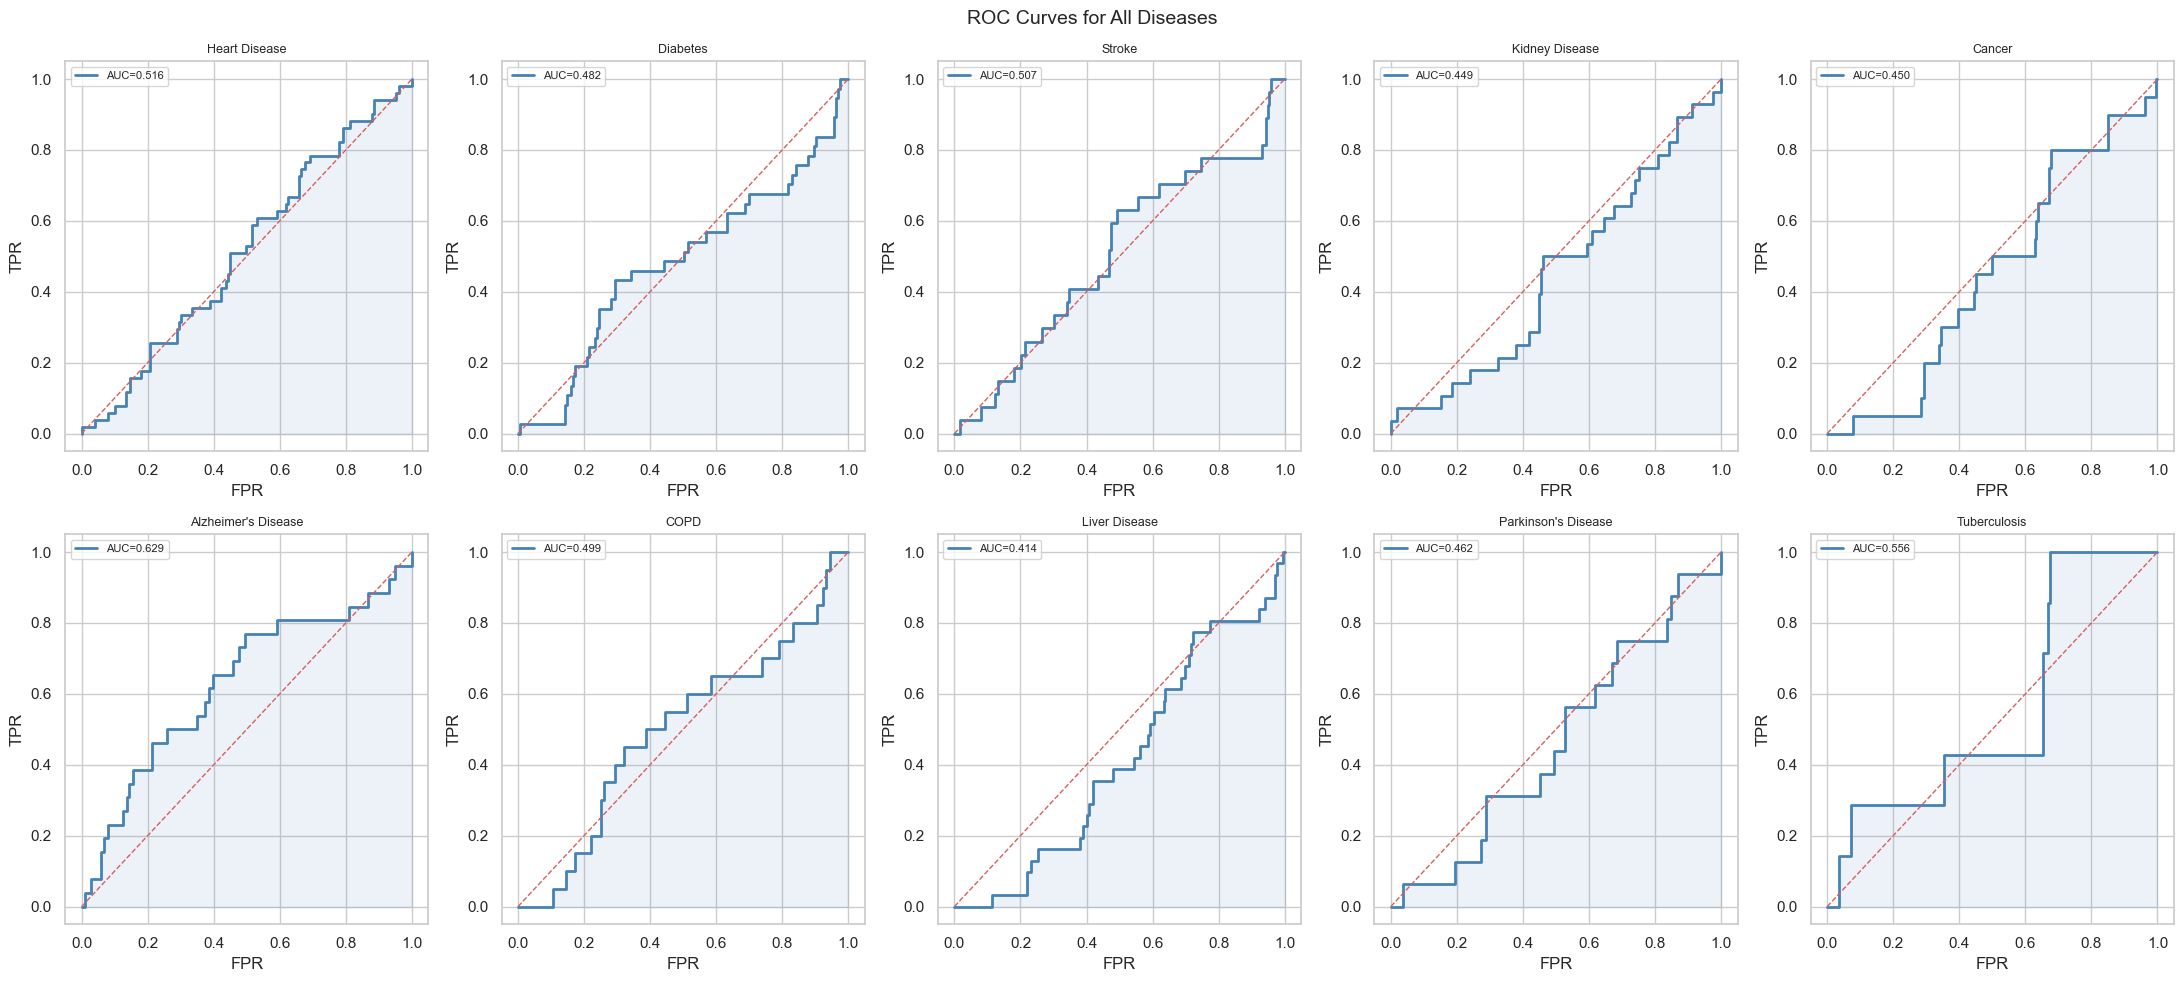

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, (disease, res) in enumerate(results.items()):
    try:
        fpr, tpr, _ = roc_curve(res["y_test"], res["y_proba"])
        axes[i].plot(fpr, tpr, color="steelblue", linewidth=2,
                     label=f"AUC={res['auc']:.3f}")
        axes[i].fill_between(fpr, tpr, alpha=0.1, color="steelblue")
    except:
        pass
    axes[i].plot([0,1],[0,1],"r--", linewidth=1)
    axes[i].set_title(disease, fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel("FPR")
    axes[i].set_ylabel("TPR")

plt.suptitle("ROC Curves for All Diseases", fontsize=14)
plt.tight_layout()
plt.show()


## 9️⃣ Feature Importance per Disease

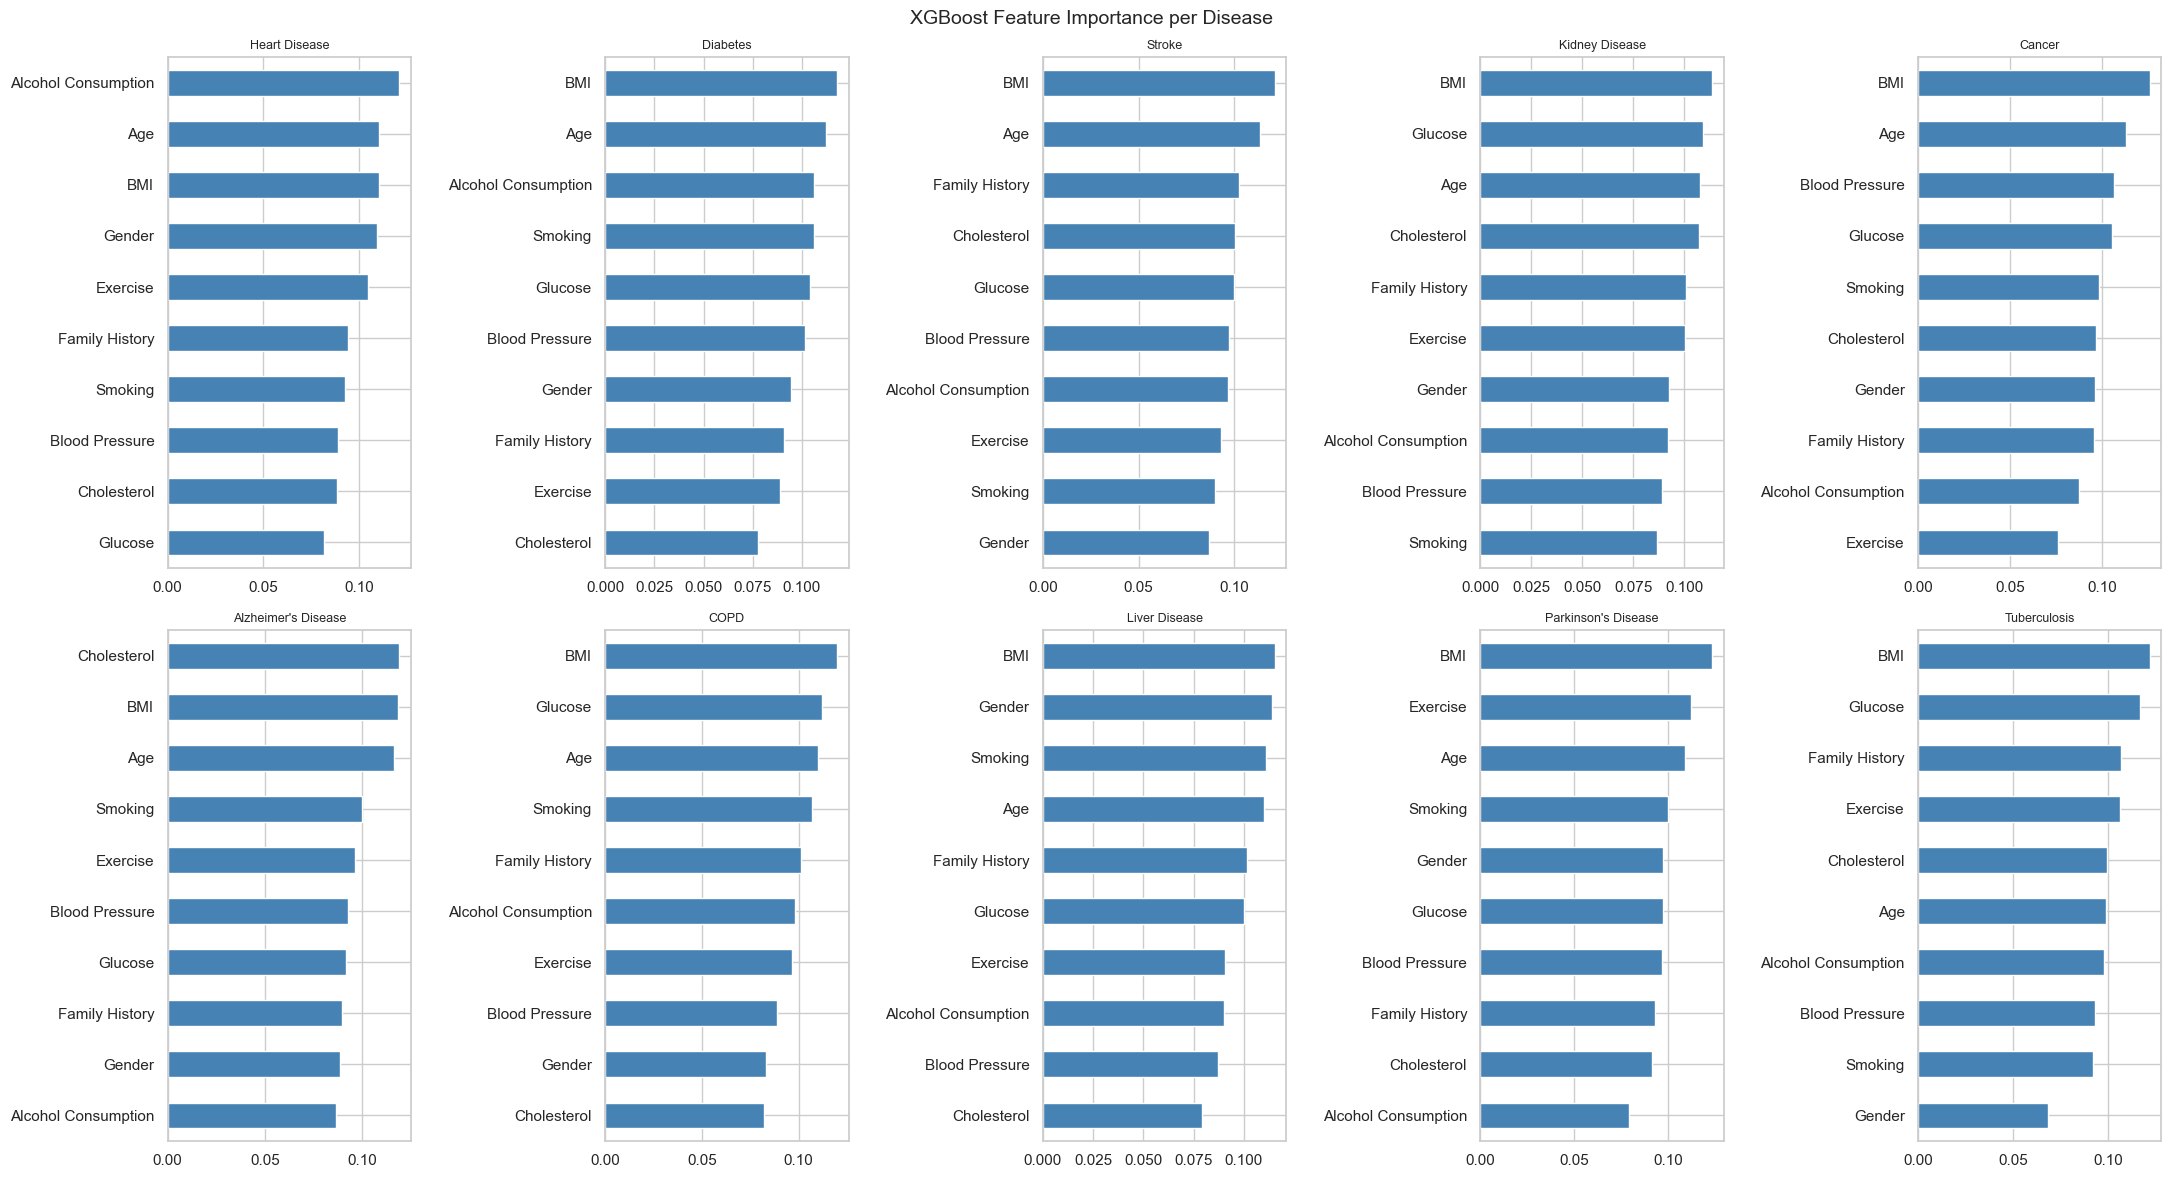

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(22, 12))
axes = axes.flatten()

for i, (disease, res) in enumerate(results.items()):
    imp = pd.Series(res["model"].feature_importances_, index=feature_cols)
    imp.sort_values().plot(kind="barh", ax=axes[i], color="steelblue")
    axes[i].set_title(f"{disease}", fontsize=9)

plt.suptitle("XGBoost Feature Importance per Disease", fontsize=14)
plt.tight_layout()
plt.show()


### 🏆 Overall Most Important Features (Average across all diseases)

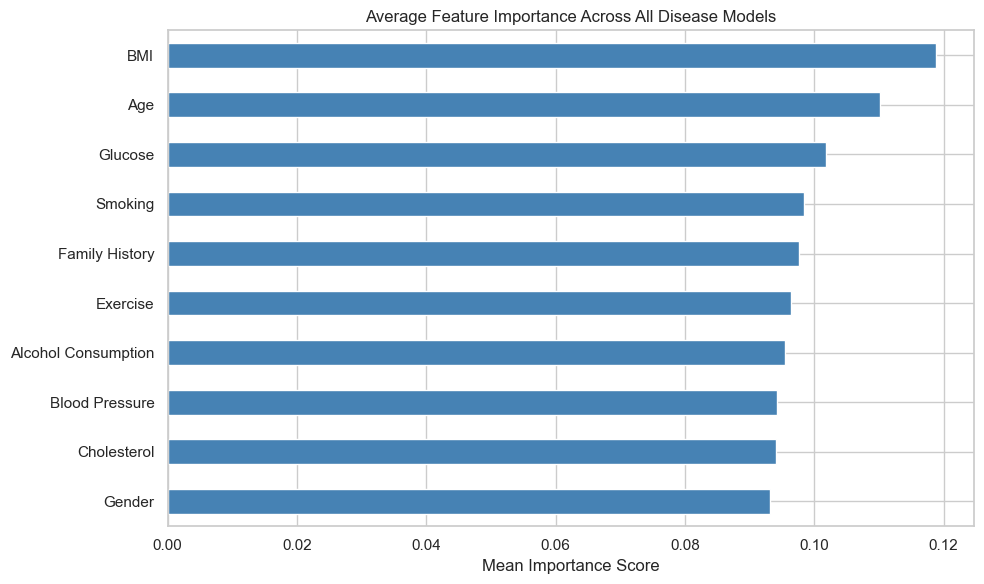


Top 3 most important features:
BMI        0.118758
Age        0.110142
Glucose    0.101752
dtype: float32


In [23]:
all_importances = pd.DataFrame({
    disease: res["model"].feature_importances_
    for disease, res in results.items()
}, index=feature_cols)

mean_importance = all_importances.mean(axis=1).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
mean_importance.plot(kind="barh", color="steelblue")
plt.title("Average Feature Importance Across All Disease Models")
plt.xlabel("Mean Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
print(mean_importance.sort_values(ascending=False).head(3))


## 🔟 Confusion Matrices

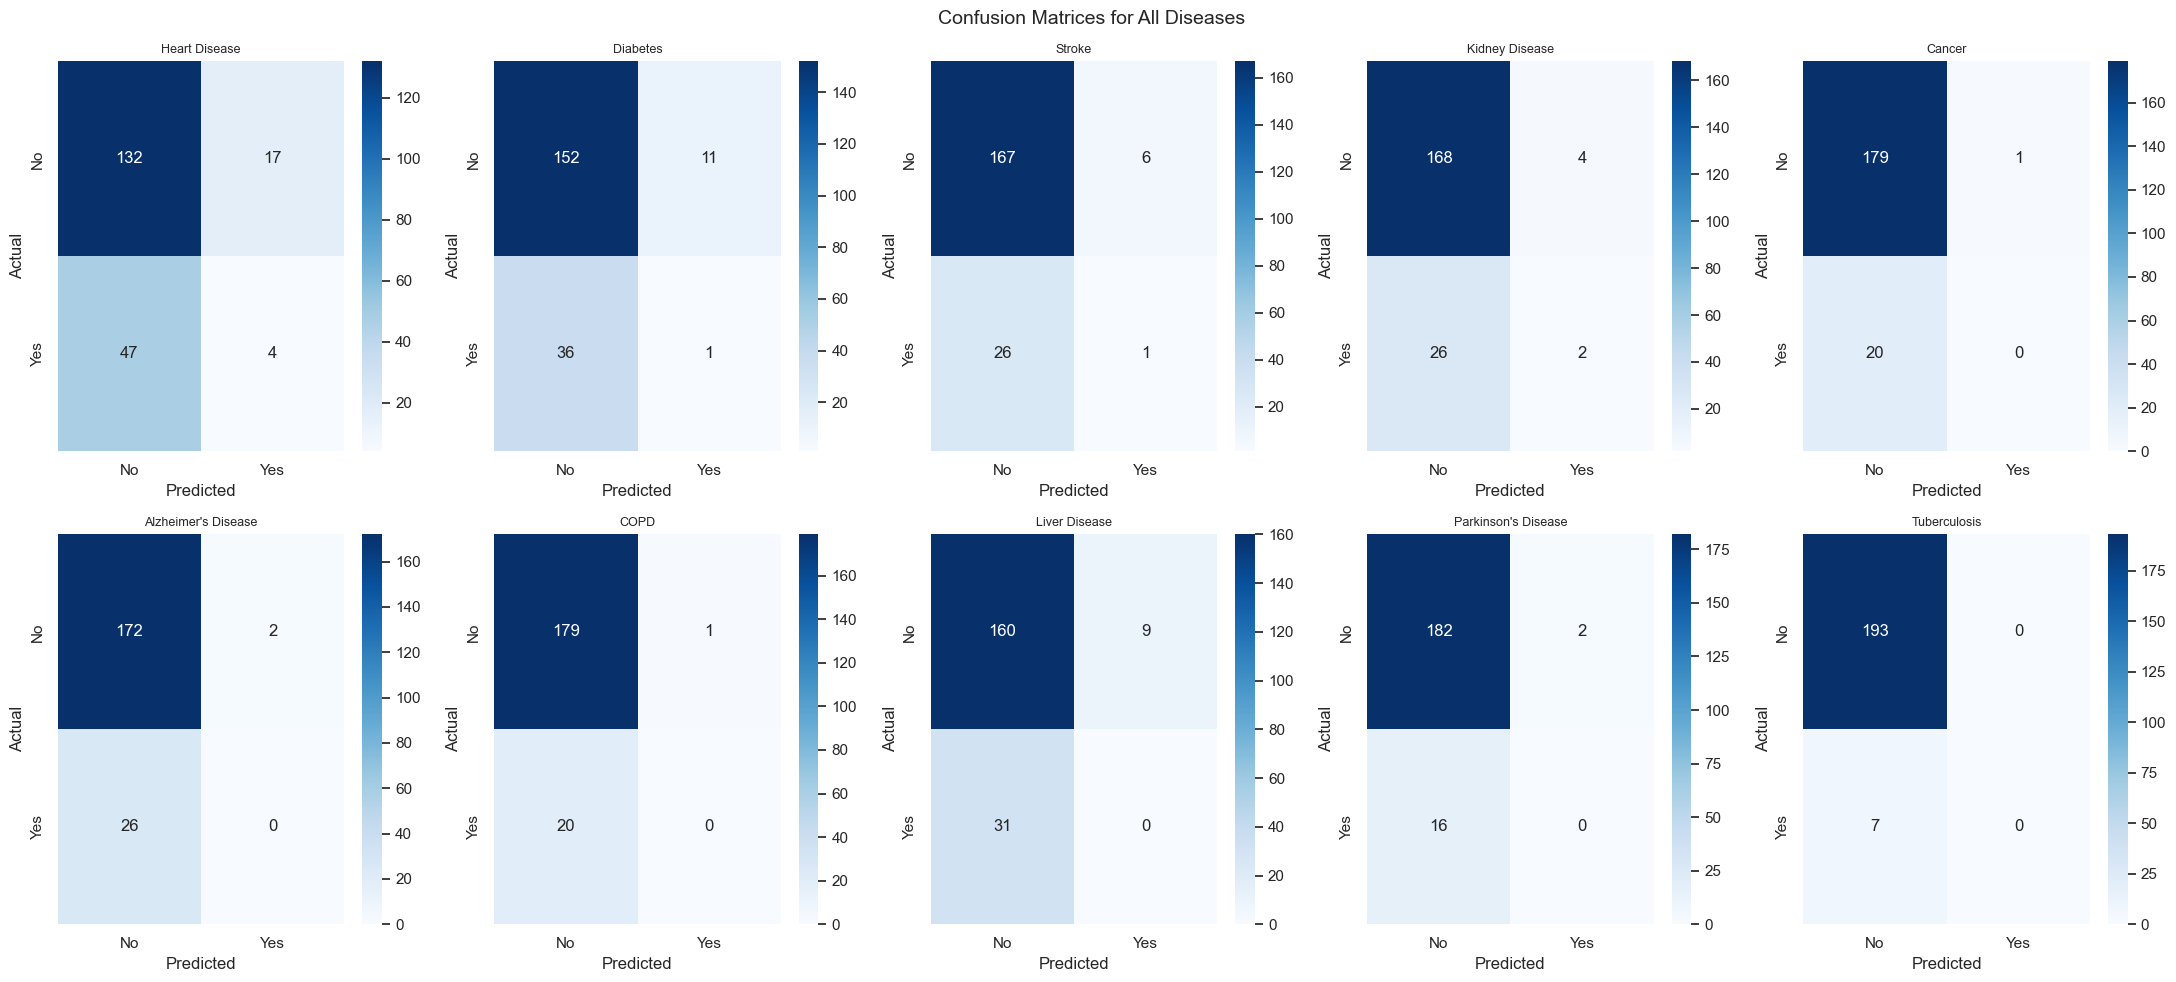

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, (disease, res) in enumerate(results.items()):
    cm = confusion_matrix(res["y_test"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    axes[i].set_title(f"{disease}", fontsize=9)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle("Confusion Matrices for All Diseases", fontsize=14)
plt.tight_layout()
plt.show()


## 1️⃣1️⃣ Predict for a New Patient

In [25]:
# Example: 55-year-old male smoker with high BP and family history
new_patient = pd.DataFrame([{
    "Age": 55,
    "Gender": 1,               # 1 = Male
    "Blood Pressure": 1,       # 1 = High
    "Cholesterol": 1,          # 1 = High
    "Glucose": 1,              # 1 = High
    "Smoking": 1,              # 1 = Yes
    "Alcohol Consumption": 0,  # 0 = No
    "Exercise": 0,             # 0 = No
    "BMI": 32.5,
    "Family History": 1        # 1 = Yes
}])

print("=" * 50)
print("  Patient Risk Assessment")
print("=" * 50)

for disease, res in results.items():
    prob = res["model"].predict_proba(new_patient)[0][1]
    risk = "🔴 HIGH" if prob > 0.5 else "🟡 MEDIUM" if prob > 0.3 else "🟢 LOW"
    print(f"  {disease:<25} → {prob:.1%}  {risk}")

print("=" * 50)


  Patient Risk Assessment
  Heart Disease             → 44.5%  🟡 MEDIUM
  Diabetes                  → 5.3%  🟢 LOW
  Stroke                    → 15.0%  🟢 LOW
  Kidney Disease            → 3.9%  🟢 LOW
  Cancer                    → 16.1%  🟢 LOW
  Alzheimer's Disease       → 18.4%  🟢 LOW
  COPD                      → 0.7%  🟢 LOW
  Liver Disease             → 11.8%  🟢 LOW
  Parkinson's Disease       → 1.6%  🟢 LOW
  Tuberculosis              → 1.3%  🟢 LOW


---
## ✅ Summary

| Step | Details |
|------|---------|
| **Dataset** | 1,000 patients · 10 input features · 10 disease targets |
| **Problem Type** | Multi-Label Binary Classification |
| **EDA** | Prevalence, demographics, risk factors, co-occurrence heatmap |
| **Preprocessing** | LabelEncoder for categoricals, no missing values |
| **Model** | XGBoost — one classifier per disease (Binary Relevance) |
| **Hyperparameters** | 200 trees, max_depth=4, lr=0.1, subsample=0.8 |
| **Evaluation** | Accuracy, ROC-AUC, Confusion Matrix, ROC Curves |
| **Key Insight** | Age, BMI, and Family History are the top predictors across most diseases |
